## Trabajo en equipo Módulo 5 Diplomado en Python & Data Science
## Número Grupo: 5

# INTEGRANTES DEL GRUPO:

### Bastián Tapia
### Miguel Diaz
### Sebastián Muñoz
### Jorge Niochet
### Luis Solar

# Indicaciones

## A. Objetivos de la tarea

El objetivo de esta tarea es desarrollar y aplicar un modelo de machine learning para predecir el número de personas que no asisten a abordar los vuelos de la aerolínea AeroML, basándose en distintos parámetros como ruta, día de la semana, hora del día, entre otros.

## B. Prerrequisitos para desarrollar la tarea

Antes de trabajar en esta tarea deben haber comprendido los contenidos de la unidad de sobre algoritmos de aprendizaje supervisado, especialmente la temática sobre regresión.

## C. Instrucciones para la elaboración de la tarea

REQUISITOS GENERALES

1. **Análisis exploratorio de los datos**<p>
2. **Preparación de los datos**<p>
3. **Extracción de atributos de la fecha**<p>
4. **Selección de variables**<p>
5. **Desarrollo del modelo**<p>
6. **Reflexione sobre el modelo**<p>
7. **Evaluación del modelo**<p>
8. **Reflexión final**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Cargar los datos
#from google.colab import files
#files.upload()
data = pd.read_csv("datos_vuelos_AeroML.csv", parse_dates=["fecha", "hora_salida"])

In [ ]:
## Visualizar Data
data

,id,fecha,numero_vuelo,origen,destino,distancia,inasistencia,vuelo_denegado,tarifa_mediabaja,tarifa_alta,...,pax_freqflyer,agendado_grupal,sin_stock,conexion_nacional,conexion_internacional,sin_conexion,hora_salida,capacidad,venta_usd,agendados
0,69922,2009-02-23,8942,ANF,SCL,1106,7,0,124.0,5,...,20,0,0,0,0,259.0,2024-12-28 21:15:00,168,8399.7,259.0
1,469723,2010-01-13,8941,SCL,ANF,1106,18,0,56.0,0,...,4,0,0,7,6,96.0,2024-12-28 18:15:00,174,8535.7,109.0
2,779308,2010-10-04,9128,ANF,SCL,1106,6,0,1.0,0,...,2,0,0,0,1,78.0,2024-12-28 17:26:00,218,3525.4,79.0
3,429392,2009-12-11,7941,SCL,ANF,1106,10,0,122.0,2,...,14,0,0,11,1,223.0,2024-12-28 20:20:00,174,10578.4,235.0
4,1286557,2011-11-20,9139,SCL,ANF,1106,8,0,1.0,0,...,14,0,1,0,1,199.0,2024-12-28 07:47:00,220,5769.4,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18317,263038,2009-07-31,8930,ANF,SCL,1106,1,0,63.0,1,...,7,0,0,2,0,113.0,2024-12-28 13:25:00,174,14535.7,115.0
18318,267247,2009-08-03,9130,ANF,SCL,1106,11,0,129.0,3,...,14,0,0,1,0,274.0,2024-12-28 17:45:00,218,9081.9,275.0
18319,627531,2010-06-01,8926,ANF,SCL,1106,9,0,96.0,1,...,9,0,0,1,5,193.0,2024-12-28 00:40:00,0,8202.8,199.0
18320,900155,2011-01-13,9145,SCL,ANF,1106,0,0,0.0,0,...,4,0,0,5,1,73.0,2024-12-28 05:20:00,174,4406.6,79.0


In [ ]:
### Lista de columnas para visualizar
print(data.columns.tolist())

['id', 'fecha', 'numero_vuelo', 'origen', 'destino', 'distancia', 'inasistencia', 'vuelo_denegado', 'tarifa_mediabaja', 'tarifa_alta', 'tarifa_mediaalta', 'tarifa_baja', 'pax_freqflyer', 'agendado_grupal', 'sin_stock', 'conexion_nacional', 'conexion_internacional', 'sin_conexion', 'hora_salida', 'capacidad', 'venta_usd', 'agendados']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18322 entries, 0 to 18321
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      18322 non-null  int64         
 1   fecha                   18322 non-null  datetime64[ns]
 2   numero_vuelo            18322 non-null  int64         
 3   origen                  18322 non-null  object        
 4   destino                 18322 non-null  object        
 5   distancia               18322 non-null  int64         
 6   inasistencia            18322 non-null  int64         
 7   vuelo_denegado          18322 non-null  int64         
 8   tarifa_mediabaja        17315 non-null  float64       
 9   tarifa_alta             18322 non-null  int64         
 10  tarifa_mediaalta        18322 non-null  int64         
 11  tarifa_baja             18322 non-null  int64         
 12  pax_freqflyer           18322 non-null  int64 

In [ ]:
data.describe(include='all')

,id,fecha,numero_vuelo,origen,destino,distancia,inasistencia,vuelo_denegado,tarifa_mediabaja,tarifa_alta,...,pax_freqflyer,agendado_grupal,sin_stock,conexion_nacional,conexion_internacional,sin_conexion,hora_salida,capacidad,venta_usd,agendados
count,1.832200e+04,18322,18322.000000,18322,18322,18322.0,18322.000000,18322.000000,17315.000000,18322.000000,...,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,18048.000000,18317,18322.000000,18322.000000,17681.000000
unique,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,SCL,ANF,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,9184,9184,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.129082e+05,2010-05-17 01:14:30.428992512,8960.270276,NaN,NaN,1106.0,8.327148,0.055180,50.279873,2.717607,...,11.110523,3.858804,0.072863,10.299858,4.090929,137.524601,2024-12-28 14:25:15.205546752,177.890460,10767.573158,152.004864
min,1.580000e+02,2009-01-02 00:00:00,7926.000000,NaN,NaN,1106.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024-12-28 00:01:00,0.000000,193.700000,3.000000
25%,2.771338e+05,2009-08-11 00:00:00,8933.000000,NaN,NaN,1106.0,5.000000,0.000000,2.000000,0.000000,...,6.000000,0.000000,0.000000,1.000000,1.000000,89.000000,2024-12-28 09:55:00,174.000000,6517.850000,102.000000
50%,5.752390e+05,2010-04-15 00:00:00,9126.000000,NaN,NaN,1106.0,8.000000,0.000000,36.000000,1.000000,...,10.000000,0.000000,0.000000,5.000000,2.000000,127.000000,2024-12-28 14:55:00,174.000000,9595.400000,144.000000
75%,9.329845e+05,2011-02-07 00:00:00,9138.000000,NaN,NaN,1106.0,11.000000,0.000000,97.000000,3.000000,...,15.000000,0.000000,0.000000,13.000000,5.000000,184.000000,2024-12-28 19:05:00,218.000000,13753.200000,201.000000
max,1.350202e+06,2012-01-08 00:00:00,9251.000000,NaN,NaN,1106.0,79.000000,20.000000,185.000000,109.000000,...,84.000000,158.000000,1.000000,181.000000,89.000000,366.000000,2024-12-28 23:59:00,274.000000,52995.600000,384.000000


## TIP: Puede extraer información de las fechas de la siguiente manera:

```python

data['año'] = data['fecha'].dt.year

## Descripción de Variables en el Conjunto de Datos de Vuelos

### Variables Principales

1. **`id`**:  
   - Identificador único para cada registro.
   - Útil para indexación y combinación de datos.
  
2. **`fecha`**:  
   - Fecha del vuelo.
   - Importante para el análisis temporal y la identificación de patrones estacionales o tendencias.
  
3. **`numero_vuelo`**:  
   - Identificador único del vuelo.
   - Sirve para rastrear la eficiencia y popularidad de rutas específicas.
  
4. **`origen` y `destino`**:  
   - Aeropuertos de origen y destino.
   - Pueden usarse para analizar la demanda entre diferentes ubicaciones.

5. **`distancia`**:  
   - Distancia entre el origen y el destino.
   - Puede influir en la tarifa y el consumo de combustible.

6. **`capacidad`**:  
   - Número total de asientos en el avión.
   - Útil para calcular la tasa de ocupación y eficiencia del vuelo.

7. **`venta_usd`**:  
   - Ingresos totales del vuelo en dólares estadounidenses.
   - Un KPI clave para la rentabilidad.

8. **`agendados`**:  
   - Número total de reservas para el vuelo.
   - Indica la demanda y permite calcular la tasa de ocupación.

### Variables de Pasajeros

9. **`inasistencia`**:  
   - Número de pasajeros que no se presentaron.
   - Esto puede afectar la rentabilidad y requiere estrategias de overbooking cuidadosas.

10. **`vuelo_denegado`**:  
    - Número de pasajeros que no pudieron abordar debido al exceso de reservas.
    - Importante para evaluar la eficiencia del algoritmo de overbooking.

### Variables de Tarifas

11. **`tarifa_mediabaja`, `tarifa_alta`, `tarifa_mediaalta`, `tarifa_baja`**:  
    - Distribución de los tipos de tarifas adquiridas.
    - Esto puede ayudar a segmentar a los clientes y ajustar las estrategias de precios.

12. **`pax_freqflyer`**:  
    - Número de pasajeros que redimieron millas.
    - Importante para medir el compromiso del cliente.

13. **`agendado_grupal`**:  
    - Número de reservas grupales.
    - Estos suelen tener tarifas más bajas y podrían afectar la rentabilidad.

### Variables de Conexión

14. **`conexion_nacional`, `conexion_internacional`, `sin_conexion`**:  
    - Indican si el vuelo es parte de una conexión nacional, internacional o si los pasajeros no están en una conexión.
    - Esto puede afectar la logística y la planificación.

### Variables Adicionales

15. **`sin_stock`**:  
    - Variable binaria que muestra los días sin capacidad para vender más boletos.
    - Un indicador de alta demanda que podría usarse para ajustar tarifas o frecuencias de vuelo.

16. **`year`, `month`, `day`, `day_of_week`, `hour`**:  
    - Variables temporales que pueden ser útiles para modelar efectos estacionales o patrones diurnos.


# 1. Análisis Exploratorio y Preparación de Datos (se evalúa acá pero no importa si se realiza más adelante)

Realice un análisis exploratorio y una preparación de datos que incluya:
- La gestión de valores faltantes o nulos (si existieran).
- La codificación de variables categóricas (si existieran).
- La normalización o estandarización de los datos.

**Comentarios:**
- Comente si existen datos faltantes, si hay valores que no tienen sentido, si hay outliers, etc.
- Describa las decisiones que tomó para la limpieza, imputación y/o transformación de los datos.

**Datos Faltantes**

In [ ]:
print("Valores faltantes para cada columna:")
print(data.isnull().sum())

Valores faltantes para cada columna:
id                           0
fecha                        0
numero_vuelo                 0
origen                       0
destino                      0
distancia                    0
inasistencia                 0
vuelo_denegado               0
tarifa_mediabaja          1007
tarifa_alta                  0
tarifa_mediaalta             0
tarifa_baja                  0
pax_freqflyer                0
agendado_grupal              0
sin_stock                    0
conexion_nacional            0
conexion_internacional       0
sin_conexion               274
hora_salida                  5
capacidad                    0
venta_usd                    0
agendados                  641
dtype: int64


Se puede observar la presencia de datos faltantes: 1007 para la columna tarifa media baja, 274  para la columna sin_conexion y 641  para la columna agendados.

A continuación se muestran los porcentajes respectivos:

In [ ]:
print("\nPorcentaje de valores faltantes:")
print((data.isnull().sum() / len(data) * 100).round(2))


Porcentaje de valores faltantes:
id                        0.00
fecha                     0.00
numero_vuelo              0.00
origen                    0.00
destino                   0.00
distancia                 0.00
inasistencia              0.00
vuelo_denegado            0.00
tarifa_mediabaja          5.50
tarifa_alta               0.00
tarifa_mediaalta          0.00
tarifa_baja               0.00
pax_freqflyer             0.00
agendado_grupal           0.00
sin_stock                 0.00
conexion_nacional         0.00
conexion_internacional    0.00
sin_conexion              1.50
hora_salida               0.03
capacidad                 0.00
venta_usd                 0.00
agendados                 3.50
dtype: float64


Se puede apreciar que los valores faltantes para las columnas nombradas corresponden a porcentajes pequeños (menores a 6%) del total.

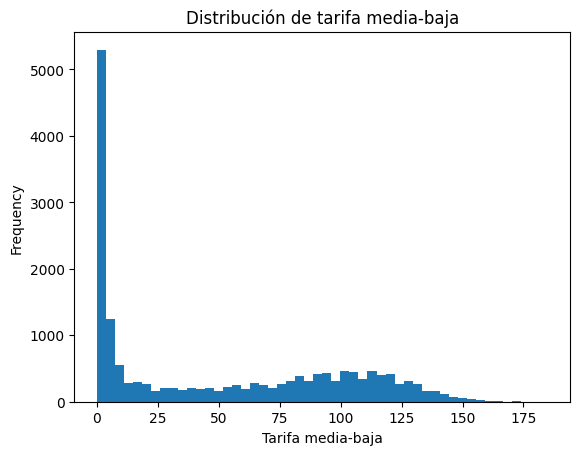

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
data['tarifa_mediabaja'].plot(kind='hist', bins=50)
plt.xlabel("Tarifa media-baja")
plt.title("Distribución de tarifa media-baja")
plt.show()

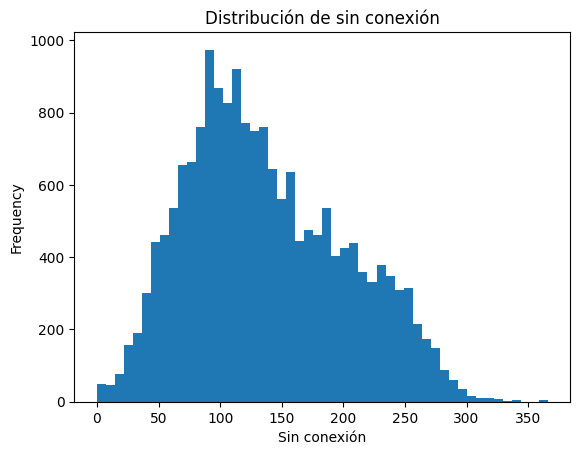

In [ ]:
data['sin_conexion'].plot(kind='hist', bins=50)
plt.xlabel("Sin conexión")
plt.title("Distribución de sin conexión")
plt.show()

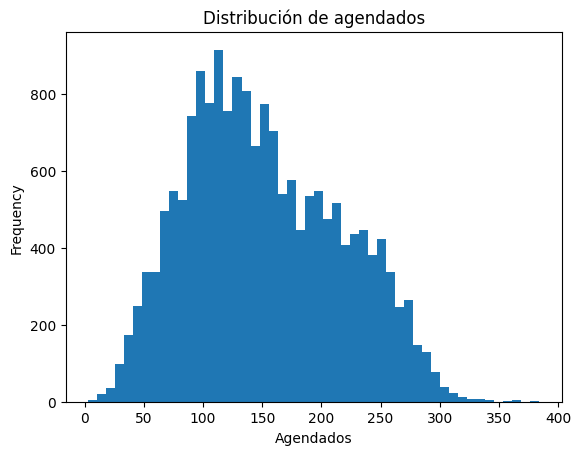

In [ ]:
data['agendados'].plot(kind='hist', bins=50)
plt.xlabel("Agendados")
plt.title("Distribución de agendados")
plt.show()

**Gestión de valores faltantes**

Se decide rellenar los datos con el valor de mediana dado que no distorsiona los datos en presencia de extremos y además permite conservar información (ante la alternativa de eliminar estos datos).

In [ ]:
### Relleno de datos con la mediana +  corregir fechas
data_clean=data.copy()
data_clean['fecha'] = pd.to_datetime(data_clean['fecha'], errors='coerce')
data_clean['hora_salida'] = pd.to_datetime(data_clean['hora_salida'], format='%H:%M:%S', errors='coerce')

data_clean.fillna(data_clean.median(numeric_only=True), inplace=True)
print("Valores faltantes para cada columna:")
print(data_clean.isnull().sum())

Valores faltantes para cada columna:
id                        0
fecha                     0
numero_vuelo              0
origen                    0
destino                   0
distancia                 0
inasistencia              0
vuelo_denegado            0
tarifa_mediabaja          0
tarifa_alta               0
tarifa_mediaalta          0
tarifa_baja               0
pax_freqflyer             0
agendado_grupal           0
sin_stock                 0
conexion_nacional         0
conexion_internacional    0
sin_conexion              0
hora_salida               5
capacidad                 0
venta_usd                 0
agendados                 0
dtype: int64


Se observa que en hora de salida hay 5 datos que siguen con problemas, se decide eliminarlos dado que corresponden a un % mínimo.

In [ ]:
### Se observan datos faltantes en hora_salida. Se opta por eliminar
data_clean = data_clean.dropna(subset=['hora_salida'])
print(data_clean.isnull().sum())

id                        0
fecha                     0
numero_vuelo              0
origen                    0
destino                   0
distancia                 0
inasistencia              0
vuelo_denegado            0
tarifa_mediabaja          0
tarifa_alta               0
tarifa_mediaalta          0
tarifa_baja               0
pax_freqflyer             0
agendado_grupal           0
sin_stock                 0
conexion_nacional         0
conexion_internacional    0
sin_conexion              0
hora_salida               0
capacidad                 0
venta_usd                 0
agendados                 0
dtype: int64


VARIABLES CATEGÓRICAS

Se observa a continuación que las variables origen y destino son del tipo categóricas. Para su tratamiento se utiliza get_dummies() para que la transformación no tenga sentido ordinal y los futuros modelos no incurran en errores de interpretación.

In [ ]:
### Categoricos
categorical_columns = data_clean.select_dtypes(include=['object', 'category']).columns
print("Variables categóricas:")
print(categorical_columns)

data_clean = pd.get_dummies(data_clean, columns=['origen', 'destino'], drop_first=True)

Variables categóricas:
Index(['origen', 'destino'], dtype='object')


In [ ]:
## Para visualizar algun dato aberrante (Min o Max) posterior al tratamiento
data_clean.describe(include='all')

,id,fecha,numero_vuelo,distancia,inasistencia,vuelo_denegado,tarifa_mediabaja,tarifa_alta,tarifa_mediaalta,tarifa_baja,...,sin_stock,conexion_nacional,conexion_internacional,sin_conexion,hora_salida,capacidad,venta_usd,agendados,origen_SCL,destino_SCL
count,1.831700e+04,18317,18317.000000,18317.0,18317.000000,18317.000000,18317.000000,18317.000000,18317.000000,18317.000000,...,18317.000000,18317.000000,18317.000000,18317.000000,18317,18317.000000,18317.000000,18317.000000,18317,18317
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9181,9181
mean,6.130330e+05,2010-05-17 03:42:28.910847744,8960.542938,1106.0,8.328875,0.055195,49.491784,2.716657,4.349948,83.477589,...,0.072883,10.300704,4.091718,137.369056,2024-12-28 14:25:15.205546752,177.886390,10767.173675,151.728285,NaN,NaN
min,1.580000e+02,2009-01-02 00:00:00,7926.000000,1106.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2024-12-28 00:01:00,0.000000,193.700000,3.000000,NaN,NaN
25%,2.774840e+05,2009-08-11 00:00:00,8933.000000,1106.0,5.000000,0.000000,2.000000,0.000000,0.000000,57.000000,...,0.000000,1.000000,1.000000,89.000000,2024-12-28 09:55:00,174.000000,6518.000000,104.000000,NaN,NaN
50%,5.753390e+05,2010-04-15 00:00:00,9126.000000,1106.0,8.000000,0.000000,36.000000,1.000000,1.000000,87.000000,...,0.000000,5.000000,2.000000,127.000000,2024-12-28 14:55:00,174.000000,9595.400000,144.000000,NaN,NaN
75%,9.330210e+05,2011-02-07 00:00:00,9138.000000,1106.0,11.000000,0.000000,94.000000,3.000000,4.000000,111.000000,...,0.000000,13.000000,5.000000,183.000000,2024-12-28 19:05:00,218.000000,13753.200000,199.000000,NaN,NaN
max,1.350202e+06,2012-01-08 00:00:00,9251.000000,1106.0,79.000000,20.000000,185.000000,109.000000,138.000000,276.000000,...,1.000000,181.000000,89.000000,366.000000,2024-12-28 23:59:00,274.000000,52995.600000,366.000000,NaN,NaN


ELIMINACIÓN DE OUTLIERS

Como muestra el siguiente gráfico, es posible notar algunos extremos. Se eliminarán los outliers para evitar su impacto en el análisis, pues se realizaron pruebas dejando los outliers, mostrando peores rendimientos en los modelos.

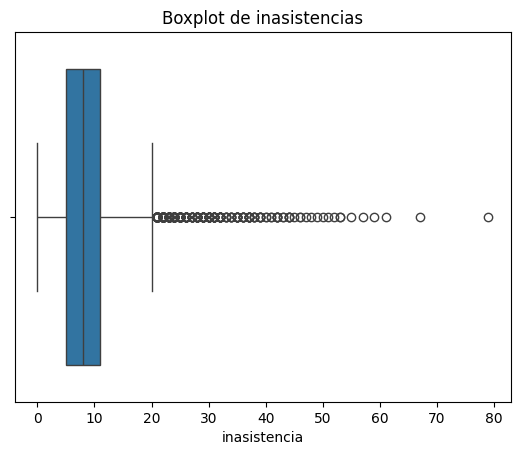

In [ ]:
# ver outliers en inasistencias
sns.boxplot(x=data_clean['inasistencia'])
plt.title('Boxplot de inasistencias')
plt.show()

In [ ]:
Q1 = data_clean['inasistencia'].quantile(0.25)
Q3 = data_clean['inasistencia'].quantile(0.75)
IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
upp = Q3 + 1.5 * IQR

# Contar cuántos valores están por encima del límite superior
outliers_superiores = (data_clean['inasistencia'] > upp).sum()

print(f'Cantidad de outliers por encima de Q3 + 1.5*IQR: {outliers_superiores}')
print(f'Porcentaje de outliers: {outliers_superiores*100/data["inasistencia"].size}%')



Cantidad de outliers por encima de Q3 + 1.5*IQR: 473
Porcentaje de outliers: 2.5815958956445804%


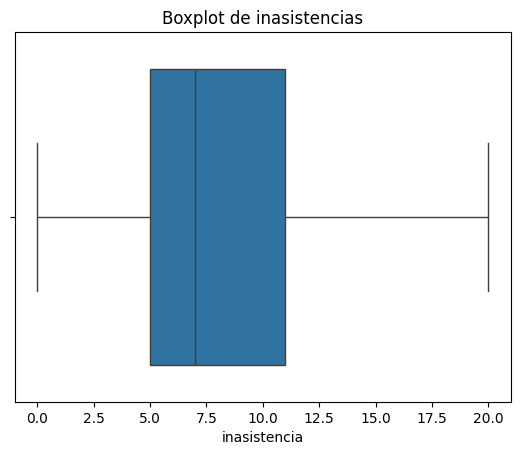

In [ ]:
# datos sin outliers
data_clean = data_clean[(data_clean['inasistencia'] >= low) & (data_clean['inasistencia'] <= upp)]

# ver outliers en inasistencias
sns.boxplot(x=data_clean['inasistencia'])
plt.title('Boxplot de inasistencias')
plt.show()

# 2. Selección de Variables y Extracción de Atributos

Elija las variables más relevantes para predecir la inasistencia y realice una extracción de atributos de la fecha. Explique las razones para dejar algunas características fuera.

**Comentarios:**
- Describa las variables que eligió y por qué.
- Explique el proceso de extracción de atributos de la fecha y su relevancia para el modelo.


Se escogieron :

1) Variables temporales porque capturan patrones estacionales, semanales y horarios que afectan la probabilidad de inasistencia [Ano, mes, dia, dia_de_semana, hora].

2) Tarifas:Afectan comportamiento y compromiso de asistencia.
 Tarifas y ventas	venta_usd, tarifa_mediabaja, tarifa_alta, tarifa_mediaalta, tarifa_baja, pax_freqflyer, agendado_grupal.

3) Logistica y llegada al vuelo: Conexión	conexion_nacional, conexion_internacional, sin_conexion.


Se eliminan:

1) Columna "id" ya que solo tiene identificadores, por lo que son datos irrelevantes para las posteriores predicciones.

2) Columna "distancia" porque la distancia es la misma en los todos los vuelos informados, por lo que esta columna también es irrelevante.

In [ ]:
#Eliminar columnas irrelevantes
data_clean = data_clean.drop(columns=['id'])
data_clean = data_clean.drop(columns=['distancia'])


**Extraccion de atributos de fecha**

La inasistencia puede estar influenciada por:

 año: por ejemplo la aplicación de restricciones de vuelo por diversos motivos

 dia_semana: día de semana puede contribuir a la inasistencia. Por ejemplo la preferencia de viajar lunes o viernes.

 dia: El numero de día mensual puede afectar, por ejemplo: viaje en dia 30 o 15.

 mes: afectado por festividades

 hora: puede influir directamente horas complicadas 6AM, 2-4PM por tráfico,etc.

In [ ]:
data_clean['ano'] = data_clean['fecha'].dt.year
data_clean['mes'] = data_clean['fecha'].dt.month
data_clean['dia'] = data_clean['fecha'].dt.day
data_clean['dia_semana'] = data_clean['fecha'].dt.dayofweek
data_clean['hora'] = pd.to_datetime(data_clean['hora_salida'], format='%H:%M:%S', errors='coerce').dt.hour

Algunos gráficos

Para analizar cualitativamente la distribución de inasistencia, boxplot por dia de semana, según mes y hora del día.

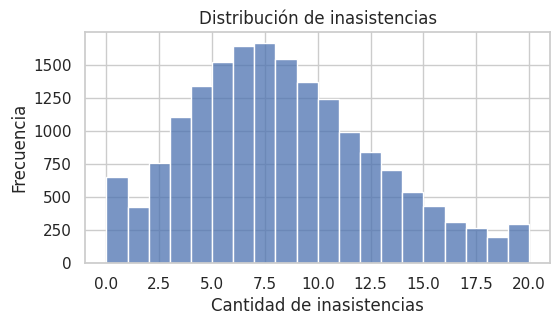

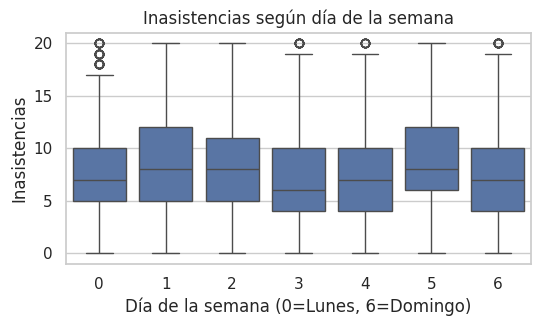

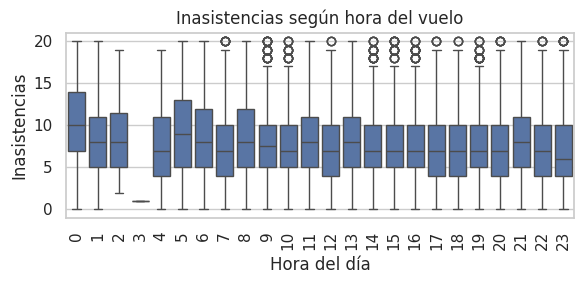

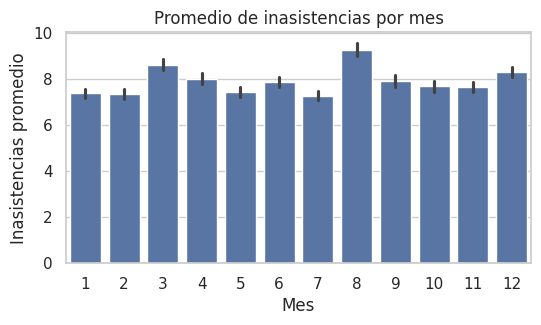

In [ ]:
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (6, 3)

# Distribución inasistencias
plt.figure()
sns.histplot(data_clean['inasistencia'], bins=20)
plt.title('Distribución de inasistencias')
plt.xlabel('Cantidad de inasistencias')
plt.ylabel('Frecuencia')
plt.show()

# 2. Boxplot de inasistencias por día de la semana
plt.figure()
sns.boxplot(x='dia_semana', y='inasistencia', data=data_clean)
plt.title('Inasistencias según día de la semana')
plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
plt.ylabel('Inasistencias')
plt.show()

# 3. Inasistencias según hora del día
plt.figure()
sns.boxplot(x='hora', y='inasistencia', data=data_clean)
plt.title('Inasistencias según hora del vuelo')
plt.xlabel('Hora del día')
plt.ylabel('Inasistencias')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 4. Tendencia mensual de inasistencias
plt.figure()
sns.barplot(x='mes', y='inasistencia', data=data_clean, estimator='mean')
plt.title('Promedio de inasistencias por mes')
plt.xlabel('Mes')
plt.ylabel('Inasistencias promedio')
plt.show()


Se pueden observar algunos aumentos de inasistencia en dias martes y sabados, en horarios anteriores a 6AM, y en meses como agosto, entre otras apreciaciones.

# 3. Desarrollo y Evaluación del Modelo

Desarrolle uno o más modelos de regresión y evalúe el desempeño de los modelos mediante el error absoluto medio (MAE). Interprete correctamente los resultados y su impacto en la precisión del modelo.

**Comentarios:**
- Describa el modelo que eligió y por qué.
- Comente sobre los resultados obtenidos del MAE y su interpretación.
- Elija otra métrica de evaluación, interprete los resultados y compare con el MAE.

Se eligieron 4 modelos:


1.   Regresión Lineal
2.   Arbol de desicion
3.   Lasso
4.   Ridge

El modelo de regresión lineal se usa como primera aproximacion. Lasso para identificar las variables más relevantes al eliminar aquellas con menor influencia (coeficientes cercanos a cero), y asi tener una interpretación más sencilla y robusta. Ridge es útil para ver los coeficientes en presencia de colinealidad. Finalmente, el modelo de árbol de decisión permitió capturar posibles relaciones no lineales entre las variables, aunque con riesgo de sobreajuste.

El MAE (error absoluto medio) resultante se encuntra en el rango 3.33-3.40 para Árbol de decisión y Lasso respectivamente. En general los cuatro modelos encontrados muestran un MAE similar, de bajo valor, es decir, un precisión alta. Dado que se encuentra en valores de inasistencia, es posible decir que el error (y con ello la precisión de la prediccion) se encuentra en aproximadamente 3 inasistencias de pasajeros por vuelo.

Se analiza el R2 siendo menor a 0.1 para todos los casos, por lo que los modelos explican menos del 10% de la variablidad de la asistencia probablemente por la falta de variables importantes, la dificultad del fenómeno o una relación muy compleja de las variables. Se recomienda a futuro integrar otras variables.


In [ ]:
# variable objetivo
y = data_clean['inasistencia']

#X = X.dropna()
#y = y.loc[X.index]

# Variables predictoras
columnasImp = [
    'ano', 'hora','mes', 'dia','dia_semana',
    'capacidad',
    'tarifa_mediabaja', 'tarifa_alta','tarifa_mediaalta', 'tarifa_baja','venta_usd',
    'pax_freqflyer', 'agendado_grupal','agendados',
    'conexion_nacional', 'conexion_internacional', 'sin_conexion'#,
#    'sin_stock'
]

#columnasImp = [
#    'sin_conexion', 'tarifa_baja', 'tarifa_mediabaja',
#    'agendados', 'hora', 'ano', 'mes',
#    'venta_usd', 'capacidad', 'conexion_nacional'
#]

# 'origen' y 'destino'
columnas_dummies = [col for col in data_clean.columns if col.startswith('origen_') or col.startswith('destino_')]

# Variables finales
X = data_clean[columnasImp + columnas_dummies]


In [ ]:
# Solo para comprobar
columnas_dummies

['origen_SCL', 'destino_SCL']

In [ ]:
data_clean.head()

,fecha,numero_vuelo,inasistencia,vuelo_denegado,tarifa_mediabaja,tarifa_alta,tarifa_mediaalta,tarifa_baja,pax_freqflyer,agendado_grupal,...,capacidad,venta_usd,agendados,origen_SCL,destino_SCL,ano,mes,dia,dia_semana,hora
0,2009-02-23,8942,7,0,124.0,5,1,109,20,0,...,168,8399.7,259.0,False,True,2009,2,23,0,21
1,2010-01-13,8941,18,0,56.0,0,1,48,4,0,...,174,8535.7,109.0,True,False,2010,1,13,2,18
2,2010-10-04,9128,6,0,1.0,0,0,76,2,0,...,218,3525.4,79.0,False,True,2010,10,4,0,17
3,2009-12-11,7941,10,0,122.0,2,4,93,14,0,...,174,10578.4,235.0,True,False,2009,12,11,4,20
4,2011-11-20,9139,8,0,1.0,0,0,185,14,0,...,220,5769.4,200.0,True,False,2011,11,20,6,7


Para predecir la variable "inasistencia", el primer modelo será de regresión lineal, ya que esta columna es numérica y continua. La regresión lineal permite realizar aprendizaje automático mediante la creación de modelos a partir de conjuntos de datos que usan objetivos continuos con variables de entrada (Pitney Bowes, 2018).

In [ ]:
# Division de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# Evaluación
y_pred = modelo_lineal.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae_lineal = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE Regresión Lineal: {mae_lineal:.2f}")
print(f"Regresión Lineal - MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Regresión Lineal - R2: {r2:.2f}")

# coeficientes
coeficientes = pd.Series(modelo_lineal.coef_, index=X.columns)
print(coeficientes.sort_values(ascending=False))


MAE Regresión Lineal: 3.35
Regresión Lineal - MSE: 18.00
RMSE: 4.24
Regresión Lineal - R2: 0.09
origen_SCL                0.223238
conexion_internacional    0.019997
tarifa_baja               0.017912
pax_freqflyer             0.014362
mes                       0.005233
sin_conexion              0.004823
agendados                 0.001511
tarifa_mediabaja          0.001078
capacidad                 0.000617
venta_usd                 0.000152
dia                      -0.017761
agendado_grupal          -0.019188
conexion_nacional        -0.023794
tarifa_alta              -0.025262
dia_semana               -0.035232
tarifa_mediaalta         -0.046814
hora                     -0.076045
destino_SCL              -0.223238
ano                      -0.940313
dtype: float64


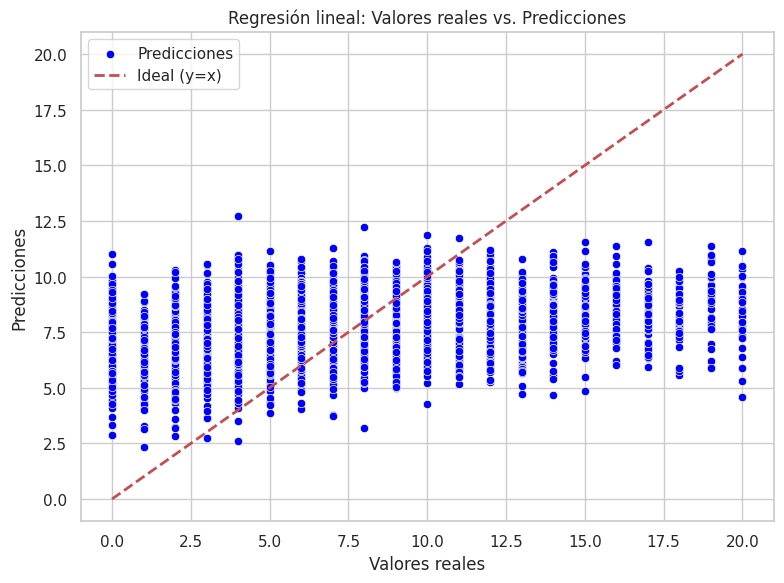

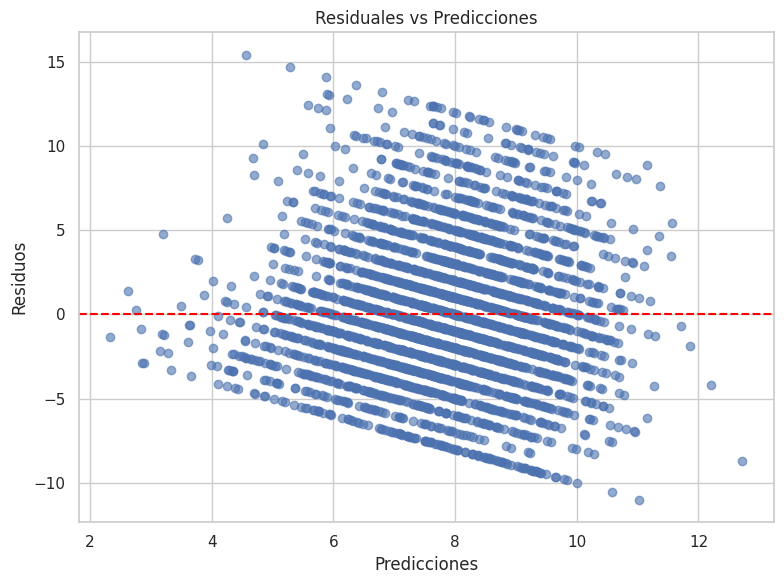

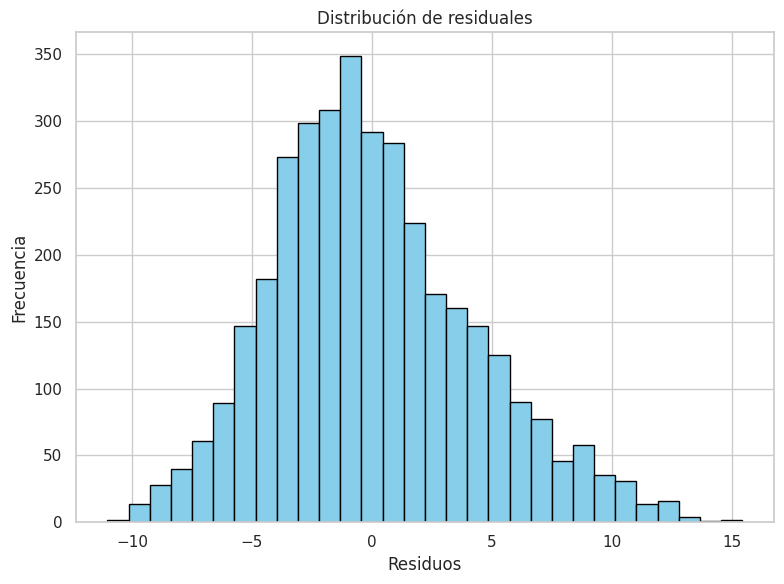

In [ ]:
# Gráfico de resultados

# ========================
# 1. Valores reales vs. predicciones
# ========================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y=x)')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Regresión lineal: Valores reales vs. Predicciones')
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 2. Gráfico de residuos
# ========================
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuales vs Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

# ========================
# 3. Histograma de residuos
# ========================
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de residuales')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se implementará el método Decision Tree Regressor para realizar las predicciones de la columna "inasistencia". Los clasificadores mediante árboles de decisión son modelos no paramétricos de aprendizaje supervisado, cuyo objetivo es poder predecir a qué clase pertenece un caso del que se conoce uno o más atributos o mediciones. El algoritmo que se utiliza para armar los árboles se denomina "partición binaria recursiva", pues en cada paso del entrenamiento del modelo el algoritmo realiza sucesivas divisiones o particiones de un subconjunto de datos a partir la aplicación de una decisión asociada a una de las variables, por ende separando a esos datos en dos nuevos subconjuntos (de allí lo de partición binaria). Siguiendo con este proceso en forma recursiva hasta un cierto punto previamente estipulado en el que el proceso de bifurcación se detiene, se obtendrá finalmente el clasificador por árbol de decisión. Cada nuevo dato, del que se conocerá el valor de sus atributos, recorrerá las sucesivas ramificaciones del árbol, a partir de las reglas y decisiones generadas mediante el proceso recién descrito (Arana, 2021). Este modelo ofrece una perspectiva diferente sobre los datos, complementando las limitaciones de los modelos lineales, pue este modelo no supone una relación lineal entre las variables independientes y la variable objetivo, lo que permite permite capturar patrones no lineales y relaciones más complejas entre variables.

In [ ]:
modelo_arbol = DecisionTreeRegressor(random_state=42, max_depth=5)
modelo_arbol.fit(X_train, y_train)
y_pred_arbol = modelo_arbol.predict(X_test)
mae_arbol = mean_absolute_error(y_test, y_pred_arbol)
mse_arbol = mean_squared_error(y_test, y_pred_arbol)
rmse_arbol = np.sqrt(mse_arbol)
r2_arbol = r2_score(y_test, y_pred_arbol)

print(f"Árbol de Decisión - MAE: {mae_arbol:.2f}")
print(f"Árbol de Decisión - MSE: {mse_arbol:.2f}")
print(f"Árbol de Decisión - RMSE: {rmse_arbol:.2f}")
print(f"Árbol de Decisión - R2: {r2_arbol:.2f}")

importancias = pd.Series(modelo_arbol.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print(importancias)

Árbol de Decisión - MAE: 3.33
Árbol de Decisión - MSE: 17.82
Árbol de Decisión - RMSE: 4.22
Árbol de Decisión - R2: 0.10
sin_conexion              0.375480
venta_usd                 0.153452
ano                       0.094683
hora                      0.078678
mes                       0.074472
origen_SCL                0.069678
conexion_nacional         0.057873
tarifa_mediabaja          0.028341
tarifa_baja               0.024957
capacidad                 0.015921
tarifa_mediaalta          0.014712
agendados                 0.007860
dia                       0.003892
tarifa_alta               0.000000
dia_semana                0.000000
pax_freqflyer             0.000000
agendado_grupal           0.000000
conexion_internacional    0.000000
destino_SCL               0.000000
dtype: float64


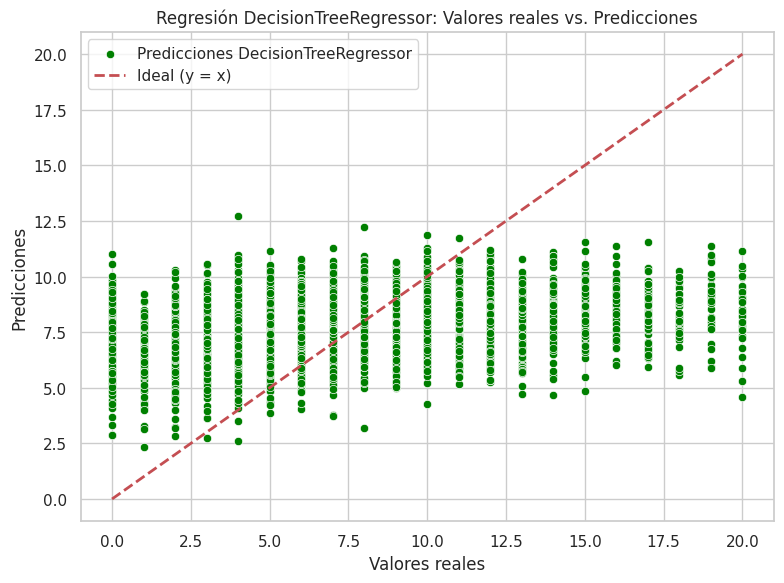

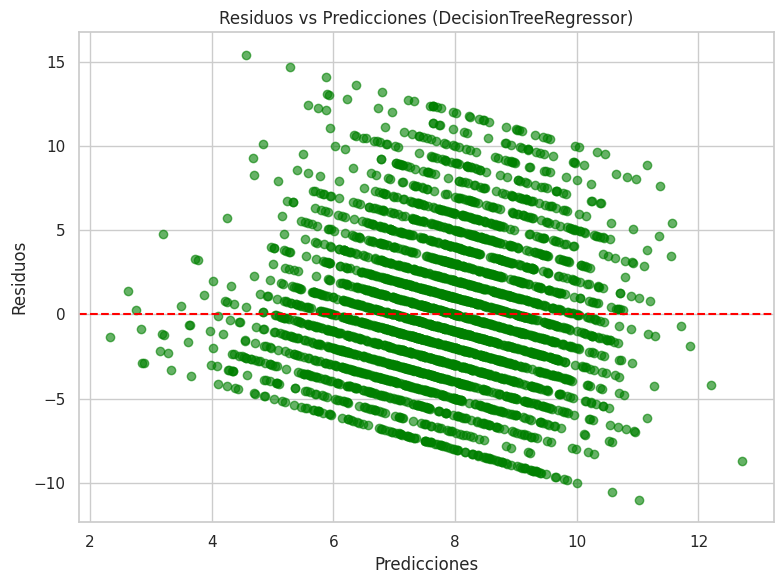

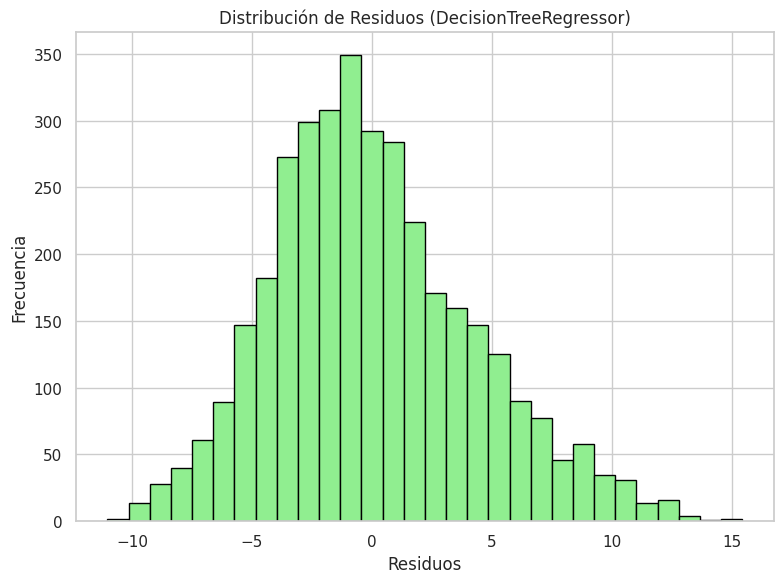

In [ ]:
# Gráfico de resultados

# ========================
# 1. Valores reales vs. predicciones
# ========================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='green', label='Predicciones DecisionTreeRegressor')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Regresión DecisionTreeRegressor: Valores reales vs. Predicciones')
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 2. Gráfico de residuos
# ========================
residuals_tree = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals_tree, alpha=0.6, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Predicciones (DecisionTreeRegressor)')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

# ========================
# 3. Histograma de residuos
# ========================
plt.figure(figsize=(8, 6))
plt.hist(residuals_tree, bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribución de Residuos (DecisionTreeRegressor)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La regresión Lasso es un método estadístico y de aprendizaje automático que selecciona y regulariza variables para aumentar la precisión y la interpretabilidad de un modelo.  En el aprendizaje automático, se utiliza con frecuencia para manejar datos de alta dimensión.  Reduce la probabilidad de sobreajuste y es útil cuando hay multicolinealidad, o correlación entre varios predictores. La función principal de Lasso es seleccionar características y regularizar modelos de datos. La regresión Lasso es un método de regularización que utiliza una penalización para detener el sobreajuste y mejorar la corrección del modelo estadístico. El objetivo principal de la regresión Lasso, es regularizar los modelos de regresión lineal. Este tipo de regresión lineal reduce o elimina parte de los coeficientes del modelo añadiendo un término de penalización a la función de coste (Bhattacharyya, 2025).



In [ ]:
modelo_lasso = Lasso(alpha=1.0)
modelo_lasso.fit(X_train, y_train)
y_pred_lasso = modelo_lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)


coef_lasso = pd.Series(modelo_lasso.coef_, index=X.columns)

print(f"Lasso - MAE: {mae_lasso:.2f}")
print(f"Lasso - MSE: {mse_lasso:.2f}")
print(f"Lasso - R2: {r2_lasso:.2f}")
print(f"Lasso - RMSE: {rmse_lasso:.2f}")
print("\nCoeficientes Lasso:")
print(coef_lasso[coef_lasso != 0].sort_values(ascending=False))

Lasso - MAE: 3.40
Lasso - MSE: 18.31
Lasso - R2: 0.07
Lasso - RMSE: 4.28

Coeficientes Lasso:
sin_conexion         0.010956
tarifa_baja          0.005911
tarifa_mediabaja     0.003495
agendados            0.002077
capacidad            0.000236
venta_usd            0.000106
dia                 -0.002397
conexion_nacional   -0.012698
agendado_grupal     -0.013149
tarifa_mediaalta    -0.025471
hora                -0.046215
dtype: float64


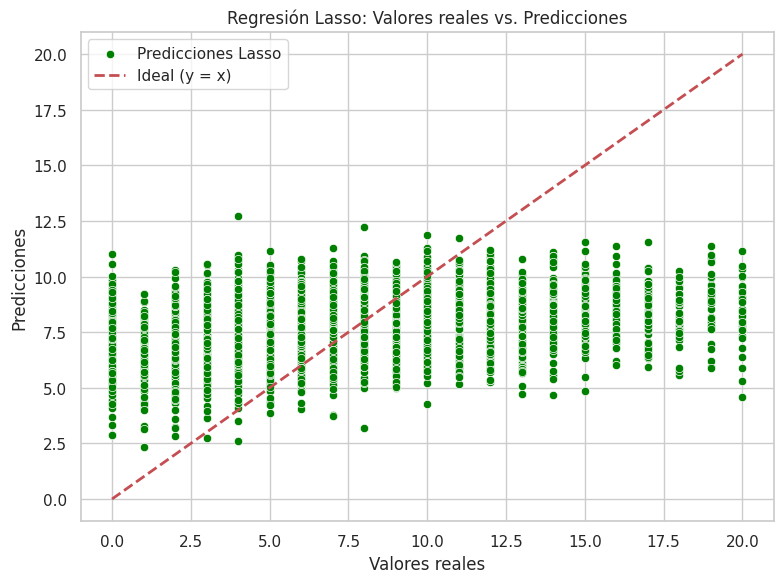

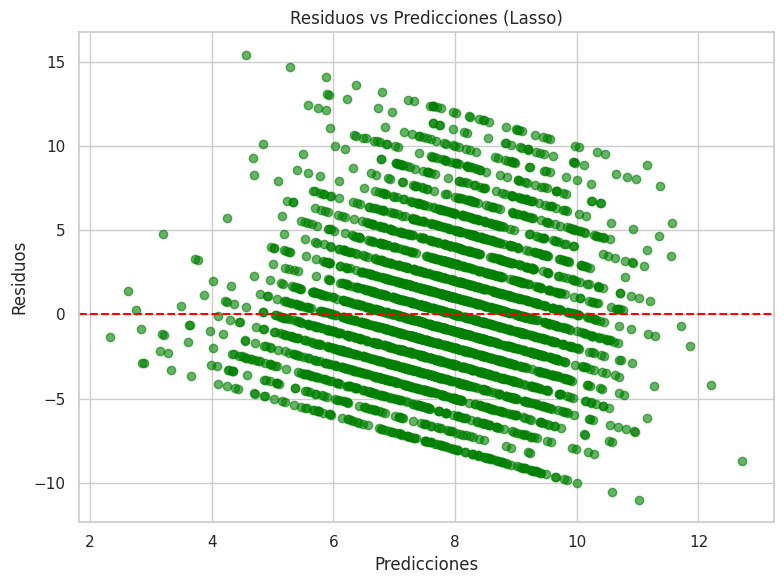

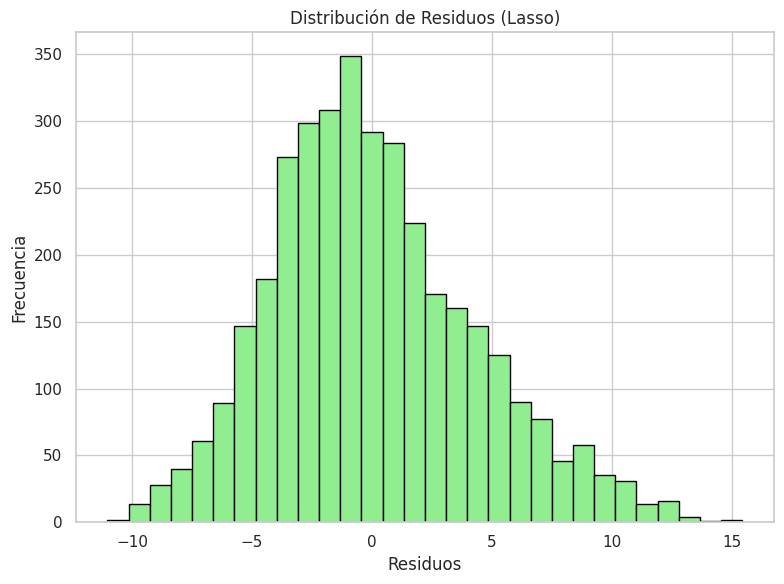

In [ ]:
# Gráfico de resultados

# ========================
# 1. Valores reales vs. predicciones
# ========================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='green', label='Predicciones Lasso')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Regresión Lasso: Valores reales vs. Predicciones')
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 2. Gráfico de residuos
# ========================
residuals_lasso = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals_lasso, alpha=0.6, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Predicciones (Lasso)')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

# ========================
# 3. Histograma de residuos
# ========================
plt.figure(figsize=(8, 6))
plt.hist(residuals_lasso, bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribución de Residuos (Lasso)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Finalmente, se utilizará el modelo de regresión Ridge. La regresión de Ridge es uno de los varios tipos de regularización para modelos de regresión lineal. La regularización es un método estadístico para reducir los errores causados por el sobreajuste en los datos de entrenamiento. La regresión de Ridge corrige específicamente la multicolinealidad en el análisis de regresión. Resulta útil cuando se desarrollan modelos de machine learning que tienen un gran número de parámetros, sobre todo si esos parámetros también tienen pesos elevados. La regresión de Ridge obtiene su parámetro de regularización a partir de la suma de errores al cuadrado (Murel & Kavlakoglu, s.f.).

In [ ]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train, y_train)
y_pred_ridge = modelo_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
coef_ridge = pd.Series(modelo_ridge.coef_, index=X.columns)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"Ridge - MAE: {mae_ridge:.2f}")
print(f"Ridge - MSE: {mse_ridge:.2f}")
print(f"Ridge - R2: {r2_ridge:.2f}")
print(f"Ridge - RMSE: {rmse_ridge:.2f}")
print("\nCoeficientes Ridge:")
print(coef_ridge.sort_values(ascending=False))

Ridge - MAE: 3.35
Ridge - MSE: 18.00
Ridge - R2: 0.09
Ridge - RMSE: 4.24

Coeficientes Ridge:
origen_SCL                0.223205
conexion_internacional    0.019995
tarifa_baja               0.017906
pax_freqflyer             0.014358
mes                       0.005255
sin_conexion              0.004825
agendados                 0.001512
tarifa_mediabaja          0.001080
capacidad                 0.000617
venta_usd                 0.000152
dia                      -0.017760
agendado_grupal          -0.019188
conexion_nacional        -0.023791
tarifa_alta              -0.025263
dia_semana               -0.035234
tarifa_mediaalta         -0.046810
hora                     -0.076045
destino_SCL              -0.223205
ano                      -0.939951
dtype: float64


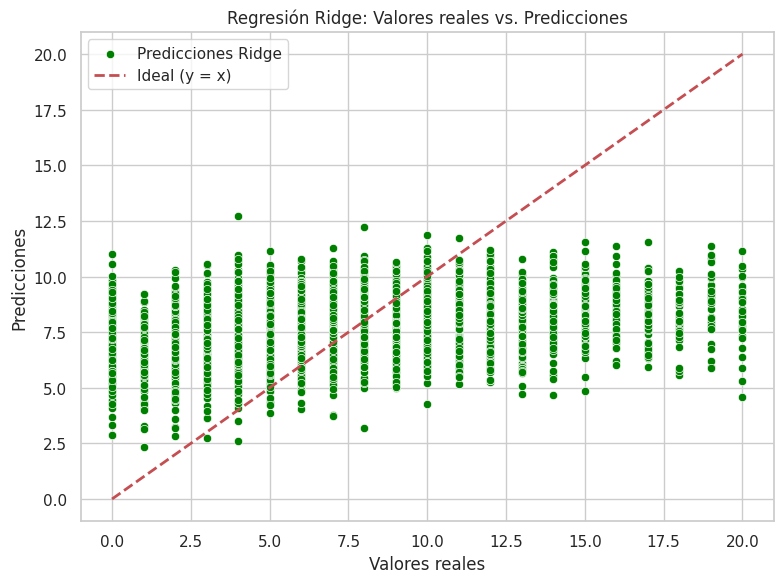

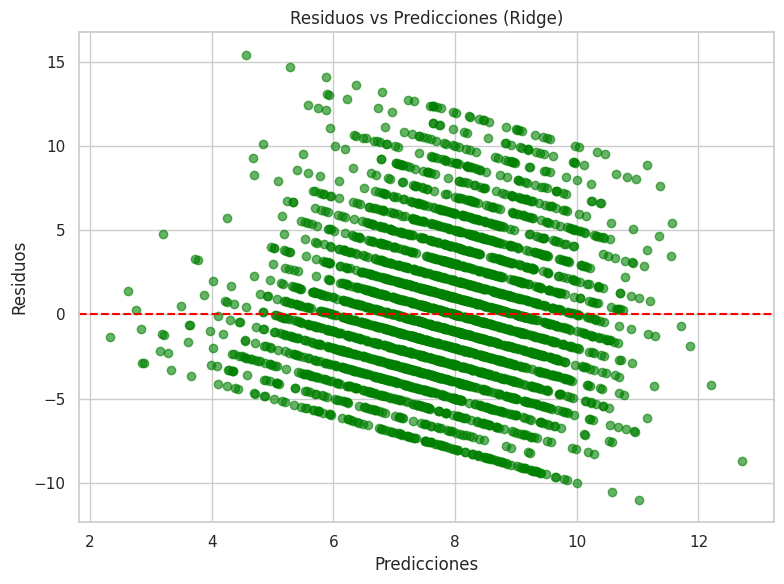

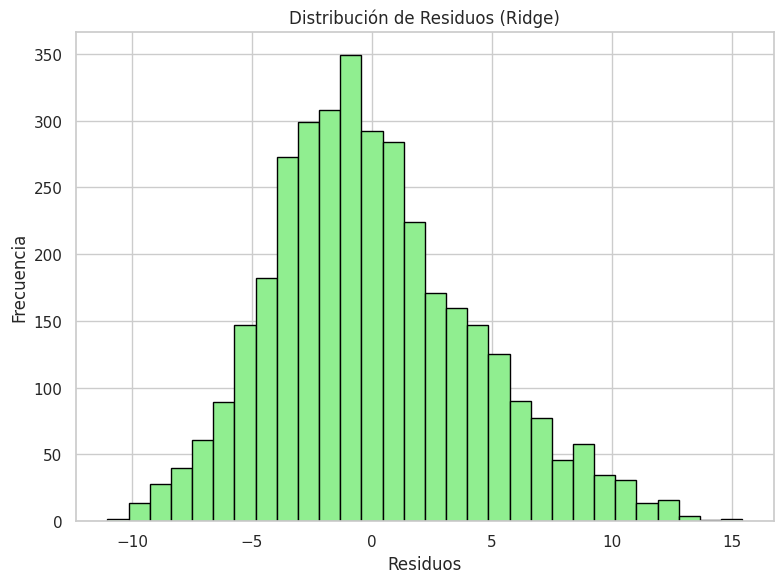

In [ ]:
# Gráfico de resultados

# ========================
# 1. Valores reales vs. predicciones
# ========================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='green', label='Predicciones Ridge')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Regresión Ridge: Valores reales vs. Predicciones')
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 2. Gráfico de residuos
# ========================
residuals_ridge = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals_ridge, alpha=0.6, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Predicciones (Ridge)')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()

# ========================
# 3. Histograma de residuos
# ========================
plt.figure(figsize=(8, 6))
plt.hist(residuals_ridge, bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribución de Residuos (Ridge)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


RESULTADOS Y COMPARACIÓN

In [ ]:
print(f"Regresión Lineal - MAE: {mae_lineal:.2f}")
print(f"Regresión Lineal - MSE: {mse:.2f}")
print(f"Regresion Lineal - RMSE: {rmse:.2f}")
print(f"Regresión Lineal - R2: {r2:.2f}")

print(f"Árbol de Decisión - MAE: {mae_arbol:.2f}")
print(f"Árbol de Decisión - MSE: {mse_arbol:.2f}")
print(f"Árbol de Decisión - RMSE: {rmse_arbol:.2f}")
print(f"Árbol de Decisión - R2: {r2_arbol:.2f}")

print(f"Lasso - MAE: {mae_lasso:.2f}")
print(f"Lasso - MSE: {mse_lasso:.2f}")
print(f"Lasso - RMSE: {rmse_lasso:.2f}")
print(f"Lasso - R2: {r2_lasso:.2f}")


print(f"Ridge - MAE: {mae_ridge:.2f}")
print(f"Ridge - MSE: {mse_ridge:.2f}")
print(f"Ridge - RMSE: {rmse_ridge:.2f}")
print(f"Ridge - R2: {r2_ridge:.2f}")

Regresión Lineal - MAE: 3.35
Regresión Lineal - MSE: 18.00
Regresion Lineal - RMSE: 4.24
Regresión Lineal - R2: 0.09
Árbol de Decisión - MAE: 3.33
Árbol de Decisión - MSE: 17.82
Árbol de Decisión - RMSE: 4.22
Árbol de Decisión - R2: 0.10
Lasso - MAE: 3.40
Lasso - MSE: 18.31
Lasso - RMSE: 4.28
Lasso - R2: 0.07
Ridge - MAE: 3.35
Ridge - MSE: 18.00
Ridge - RMSE: 4.24
Ridge - R2: 0.09


# 4. Reflexión Final

Reflexione sobre el proceso de desarrollo del modelo, las dificultades encontradas, las decisiones tomadas y la importancia de la evaluación y selección de modelos en la creación de modelos de aprendizaje automático precisos y confiables.

**Comentarios:**
- Reflexione sobre las decisiones tomadas durante el desarrollo del modelo.
- Comente las dificultades encontradas y cómo las abordó.
- Discuta la importancia de la evaluación y selección de modelos.

Durante el desarrollo del modelo predictivo para estimar las inasistencias en vuelos de AeroML, se tuvo que enfrentar un proceso completo de minería de datos: desde la exploración inicial del dataset hasta la evaluación final del modelo.

En la fase de análisis exploratorio se identificaron valores atípicos. También se observó una distribución sesgada en la variable objetivo `inasistencia`, concentrada entre 5 y 15.

Como apoyo visual, se generaron gráficos.

La preparación de datos implicó la transformación de variables categóricas (`origen`, `destino`), conversión de fechas y extracción de atributos como mes, día y hora.

Se seleccionaron variables relevantes para el modelo basándonos en intuición de negocio y análisis exploratorio.

Este trabajo permitió aplicar de forma práctica conceptos clave de machine learning, y dejó como aprendizaje la importancia de una limpieza cuidadosa, una selección reflexiva de variables y la validación cuantitativa de los resultados.



**Decisiones relevantes y dificultades respecto a limpieza de datos:**

*   Tratamiento de outliers: Se eliminaron outliers que, si bien representaban un pequeño porcentaje del total, su exclusión mejoró las métricas MAE y RMSE.
*   Tratamiento de datos faltantes: Se identificó la existencia de valores faltantes. Dado que correspondían a una proporción pequeña del total, se procedió a reemplazarlos por la mediana. Se eliminaron cinco registros con errores en las fechas.
*   Codificación de variables categóricas: Se codificaron las variables origen y destino.


**Decisiones respecto a los modelos utilizados:**

*   Se decidió dejar como variables predictoras a:
'ano', 'hora','mes', 'dia','dia_semana','capacidad','tarifa_mediabaja', 'tarifa_alta','tarifa_mediaalta', 'tarifa_baja','venta_usd' 'pax_freqflyer', 'agendado_grupal','agendados',
'conexion_nacional', 'conexion_internacional', 'sin_conexion.
 La variable objetivo fue 'inasistencia'. El objetivo fue reducir la dimensionalidad sin comprometer la calidad del modelo, siguiendo recomendaciones de Géron (2019).
*   Se compararon los modelos de Regresion lineal, Lasso , Ridge y Árbol de decisión.
* Los datos fueron divididos en entrenamiento (80%) y prueba (20%).
* El desempeño se evaluó utilizando el Error Absoluto Medio (MAE), RMSE, MSE y R2.

En todos los modelos encontrados se vio un bajo valor predictivo de R2, con valores <= 0.1 probablemente por la complejidad del fenomeno y la ausencia de variables claves. MAE resultó en un valor de 3.33 a 3.40, considerado aceptable para este tipo de problema según métricas estándar (James et al., 2023). Cabe destacar que se trabajó con una columa 'inasistencia' inicialmente con media 8.33 y desviación estándar 5.44. No se observan mayores diferencias para los modelos.

Se pudo apreciar como los modelos de aprendizaje automático dependen de la preparación de los datos, de la selección de variables y una evaluación de métricas pertinente. Tambien se demuestran los diversos contextos en los que se pueden aplicar el ML y como las decisiones pueden tener impacto operacional o económico.





# 5. Referencias bibliográficas
* Arana, C. (2021, febrero). Modelos de aprendizaje automático mediante árboles de decisión (Documento de trabajo N.º 778). Universidad del CEMA. https://ucema.edu.ar/publicaciones/download/documentos/778.pdf
* Bhattacharyya, J. (2025, marzo). LASSO Regression: A procedural improvement. Woxsen University. https://doi.org/10.13140/RG.2.2.17732.13444
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras,
and TensorFlow* (2ª ed.). O’Reilly Media.
* James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning: with Applications in Python*. Springer.
* Murel, J., & Kavlakoglu, E. (s.f.). ¿Qué es la regresión Ridge? IBM. https://www.ibm.com/es-es/think/topics/ridge-regression
* Pitney Bowes. (2018). Spectrum™ Technology Platform: Guía de Machine Learning (Versión 2018.2.0). https://docs.precisely.com/docs/sftw/spectrum/18.2/es/pdf/Spectrum_2018.2.0_MachineLearningGuide.pdf
* Scikit-learn. (2021). *Cross-validation: Evaluating Estimator Performance*. https://scikit-learn.org/stable/modules/cross_validation.html



In [ ]:
from google.colab import files
data_clean.to_excel("Data_clean.xlsx",index=False)
files.download("Data_clean.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>